In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import tensorflow as tf
from tensorflow import keras

The non-linear Schrodinger equation in 1 spatial dimension is the PDE:
$$i\frac{\partial h}{\partial t} = -\frac{1}{2}\frac{\partial^2 h}{\partial x^2} + \kappa|h|^2 h$$
where $h(t,x)\in\mathbb{C}$.

Let us choose the initial and boundary conditions, and non-linearity parameter $\kappa$:
$$h(0,x) = 2\ \mathrm{sech}(x)$$
$$h(t,-5) = h(t,5)$$
$$\frac{\partial h}{\partial x}(t,-5) = \frac{\partial h}{\partial x}(t,5)$$
$$\kappa = -1$$

We want the function
$$f = i\frac{\partial h}{\partial t} + \frac{1}{2}\frac{\partial^2 h}{\partial x^2} + |h|^2 h$$
to go to zero. So we minimize $|f|^2$.

In simulations, we would've evolved $h(0,x)$ using the PDE. Here, we approximate $h(t,x)$ with a dense 2-out neural network.

The loss functions are
$$L_\mathrm{init} = \frac{1}{N_\mathrm{init}} \sum_{i\in\mathrm{init}}^{N_\mathrm{init}} \left|h_\mathrm{NN}(0,x_0^i) - h_0^i\right|^2$$
$$L_\mathrm{bound} = \frac{1}{N_\mathrm{bound}} \sum_{i\in\mathrm{bound}}^{N_\mathrm{bound}} \left(\left|h_\mathrm{NN}^i(t_b^i,-5) - h_\mathrm{NN}^i(t_b^i,+5)\right|^2 + \left|h_x^i(t_b^i,-5) - h_x^i(t_b^i,+5)\right|^2\right)$$
$$L_\mathrm{bulk} = \frac{1}{N_\mathrm{bulk}} \sum_{i\in\mathrm{bulk}}^{N_\mathrm{bulk}} \left|f_{\mathrm{NN}}(t_f^i,x_f^i)\right|^2$$
$$L_\mathrm{total} = L_\mathrm{init} + \phi_b L_\mathrm{bound} + \phi_f L_\mathrm{bulk}$$
where $\phi$ s modulate the relative importance of minimizing the losses.

Note: While TensorFlow tensors can be complex-valued, `GradientTape.gradient` only returns the gradient of the real part of complex tensors. We choose to represent complex numbers as 2-vectors; while this skips the process of splitting complex numbers, computing gradients, and putting them back, we have to manually perform a few mathematical operations.
$$h = u+iv \equiv (u,v)$$
$$f_\mathrm{real} = -\frac{\partial v}{\partial t} + \frac{1}{2}\frac{\partial^2 u}{\partial x^2} + (u^2+v^2) u$$
$$f_\mathrm{imag} = \frac{\partial u}{\partial t} + \frac{1}{2}\frac{\partial^2 v}{\partial x^2} + (u^2+v^2) v$$

In [2]:
class NeuralNetwork:
    def __init__(self, width, depth) -> None:
        self.model = self.get_model(width, depth)
        self.kappa = 1.  # non-linearity parameter
        self.N_U = 1000  # number of boundary points
        self.N_F = 10_000  # number of bulk points
        self.b_factor = 1.  # relative importance of spatial boundary
        self.f_factor = 1.  # relative importance of bulk
    
    def get_model(self, width, depth):
        model = keras.models.Sequential()
        model.add(keras.layers.InputLayer(shape=(2,)))  # (t, x)
        for _ in range(depth):
            model.add(keras.layers.Dense(width, activation='tanh'))
        model.add(keras.layers.Dense(2, activation=None))  # (real, imag)
        return model
    
    def h(self, t, x):
        y = tf.stack([t, x], axis=-1)
        return self.model(y)
    
    def h_hx(self, t, x):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(x)
            h_ = self.h(t, x)
            u_, v_ = h_[:,0], h_[:,1]
        u_x = tape.gradient(u_, x)
        v_x = tape.gradient(v_, x)
        h_x = tf.stack([u_x, v_x], axis=-1)
        return h_, h_x
    
    def f(self, t, x):
        with tf.GradientTape(persistent=True) as tape_outer:
            tape_outer.watch([t, x])
            with tf.GradientTape(persistent=True) as tape_inner:
                tape_inner.watch([t, x])
                h_ = self.h(t, x)
                u_, v_ = h_[:,0], h_[:,1]
            u_t, u_x = tape_inner.gradient(u_, [t, x])
            v_t, v_x = tape_inner.gradient(v_, [t, x])
        u_xx = tape_outer.gradient(u_x, x)
        v_xx = tape_outer.gradient(v_x, x)
        del tape_inner, tape_outer
        norm = u_**2 + v_**2
        f_r = - v_t + 0.5 * u_xx + norm * u_
        f_i = u_t + 0.5 * v_xx + norm * v_
        return f_r, f_i
    
    def boundary_t0(self):
        x = np.random.uniform(-5, 5, size=self.N_U).astype(np.float32)
        t = np.zeros_like(x, dtype=np.float32)
        u = 2 / np.cosh(x).astype(np.float32)
        v = np.zeros_like(x, dtype=np.float32)
        h = tf.stack([u, v], axis=-1)
        return t, x, h

    def get_loss(self):
        t_init, x_init, h_init = self.boundary_t0()
        # no need to split h since l2_loss sums across all axes
        loss_init = tf.reduce_mean(tf.square(self.h(t_init, x_init) - h_init))

        t_bound = tf.convert_to_tensor(np.random.uniform(0, 1, size=self.N_F), dtype=tf.float32)
        x_bound_min = -5 * tf.ones_like(t_bound)
        x_bound_max = 5 * tf.ones_like(t_bound)
        h_bound_min, hx_bound_min = self.h_hx(t_bound, x_bound_min)
        h_bound_max, hx_bound_max = self.h_hx(t_bound, x_bound_max)
        # no need to split hx since l2_loss sums across all axes
        loss_bound = tf.reduce_mean(tf.square(h_bound_min - h_bound_max)) + tf.reduce_mean(tf.square(hx_bound_min - hx_bound_max))

        t_bulk = tf.convert_to_tensor(np.random.uniform(0, 1, size=self.N_F), dtype=tf.float32)
        x_bulk = tf.convert_to_tensor(np.random.uniform(-5, 5, size=self.N_F), dtype=tf.float32)
        # no need to split f either
        loss_bulk = tf.reduce_mean(tf.square(self.f(t_bulk, x_bulk)))

        loss = loss_init + self.b_factor * loss_bound + self.f_factor * loss_bulk
        return loss, loss_init, loss_bound, loss_bulk

    @tf.function
    def train_step(self, optimizer):
        with tf.GradientTape() as tape:
            loss, loss_init, loss_bound, loss_bulk = self.get_loss()
        grads = tape.gradient(loss, self.model.trainable_variables)
        optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss, loss_init, loss_bound, loss_bulk
    
    def show_state(self, title='', mode=''):
        N_T = 64 + 1
        N_X = 128
        grid_tx = np.meshgrid(np.linspace(0, 1, N_T), np.linspace(-5, 5, N_X), indexing='ij')
        grid_t, grid_x = [tf.convert_to_tensor(t, tf.float32) for t in grid_tx]
        grid_h = self.h(tf.reshape(grid_t, (N_T*N_X,)), tf.reshape(grid_x, (N_T*N_X,)))
        grid_h = np.asarray(tf.reshape(grid_h, (N_T, N_X, 2)), dtype=float)

        if mode == 'real_imag':
            fig, axes = plt.subplots(2, 1, figsize=(20, 8), layout='tight')
            for i, ax in enumerate(axes):
                im = ax.imshow(tf.transpose(grid_h[:,:,i]), origin='lower', aspect='auto', extent=(0, 1, -5, 5), cmap='viridis')
                # ax.axhline(0, c='k', ls='--')
                plt.colorbar(im)
                ax.set_xlabel('t')
                ax.set_ylabel('x')
            axes[0].set_title(title+" (real)")
            axes[1].set_title(title+" (imag)")
            return fig, axes
        
        magnitude = np.sqrt(np.sum(grid_h**2, axis=2))
        phase = np.angle(grid_h[:,:,0] + 1j * grid_h[:,:,1])

        if mode == 'mag_phase':
            fig, ax = plt.subplots(2, 1, figsize=(20, 8), layout='tight')

            im = ax[0].imshow(np.transpose(magnitude), origin='lower', aspect='auto', extent=(0, 1, -5, 5), cmap='viridis')
            # ax[0].axhline(0, c='k', ls='--')
            plt.colorbar(im)
            ax[0].set_xlabel('t')
            ax[0].set_ylabel('x')
            ax[0].set_title(title+" (magnitude)")

            im = ax[1].imshow(np.transpose(phase), origin='lower', aspect='auto', extent=(0, 1, -5, 5), cmap='hsv')
            # ax[1].axhline(0, c='k', ls='--')
            plt.colorbar(im)
            ax[1].set_xlabel('t')
            ax[1].set_ylabel('x')
            ax[1].set_title(title+" (phase)")

            return fig, ax
        
        if mode == 'complex':
            magnitude = colors.Normalize(vmin=0, vmax=np.max(magnitude))(magnitude)
            phase = (phase + np.pi) / (2 * np.pi)
            
            cmap = plt.get_cmap('hsv')
            rgb_image = cmap(phase)

            rgb_image[..., :3] *= magnitude[..., None]

            fig, ax = plt.subplots(1, 1, figsize=(20, 4))
            ax.imshow(np.transpose(rgb_image[..., :3], (1,0,2)), origin='lower', aspect='auto', extent=(0, 1, -5, 5), cmap='viridis')
            # ax.axhline(0, c='k', ls='--')
            ax.set_xlabel('t')
            ax.set_ylabel('x')
            ax.set_title(title)
            return fig, ax
        
        raise ValueError("Invalid mode.")

In [3]:
neural_network = NeuralNetwork(width=100, depth=4)
_ = neural_network.model(tf.zeros((1, 2), dtype=tf.float32))

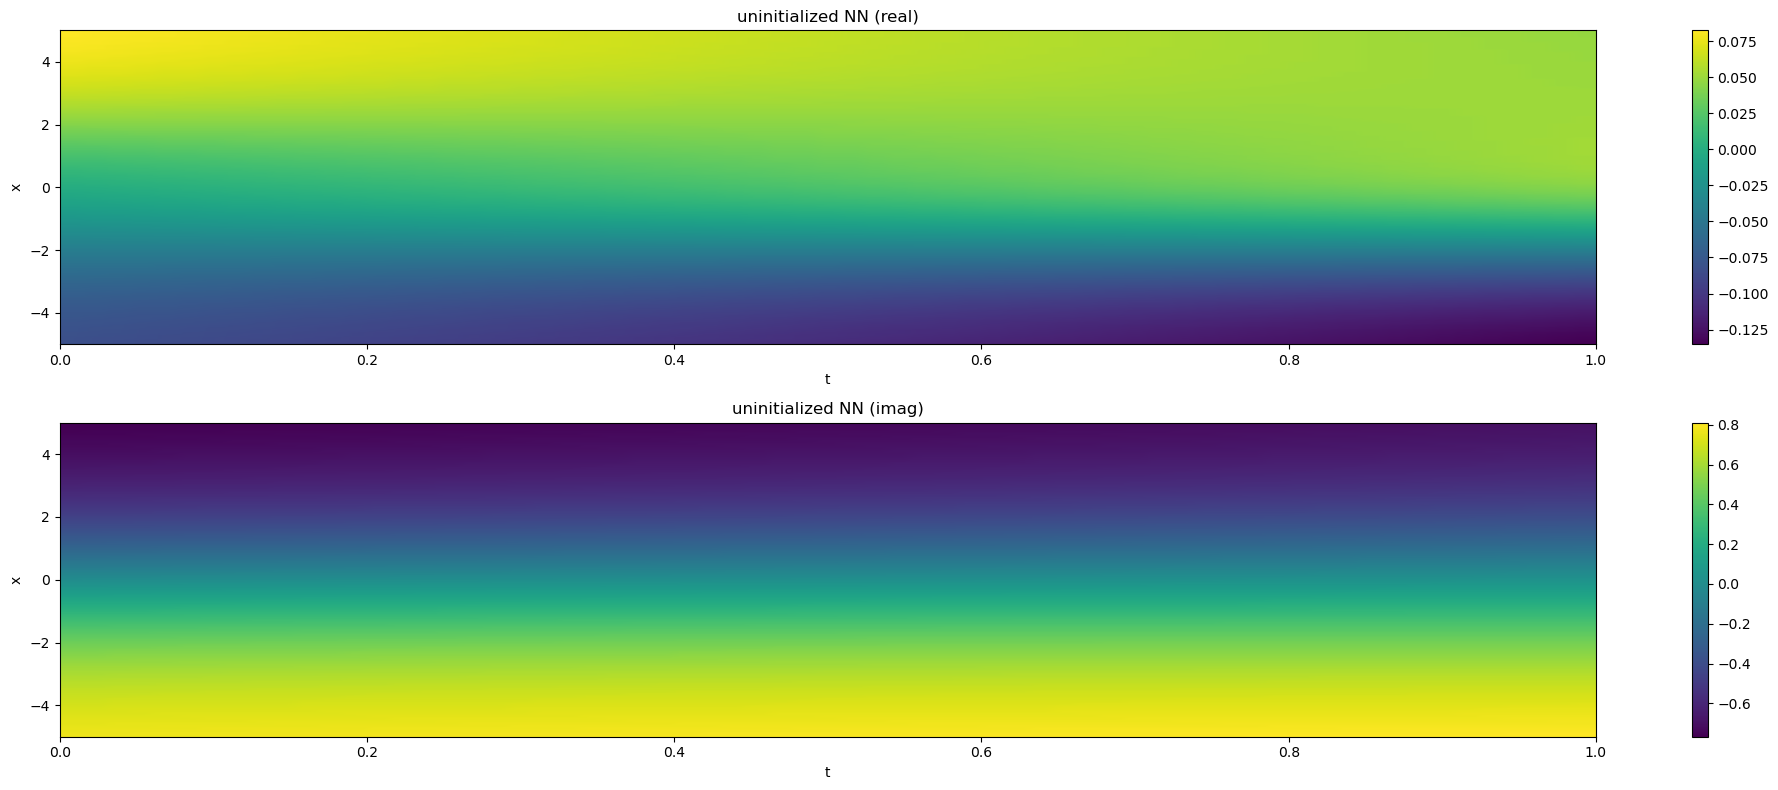

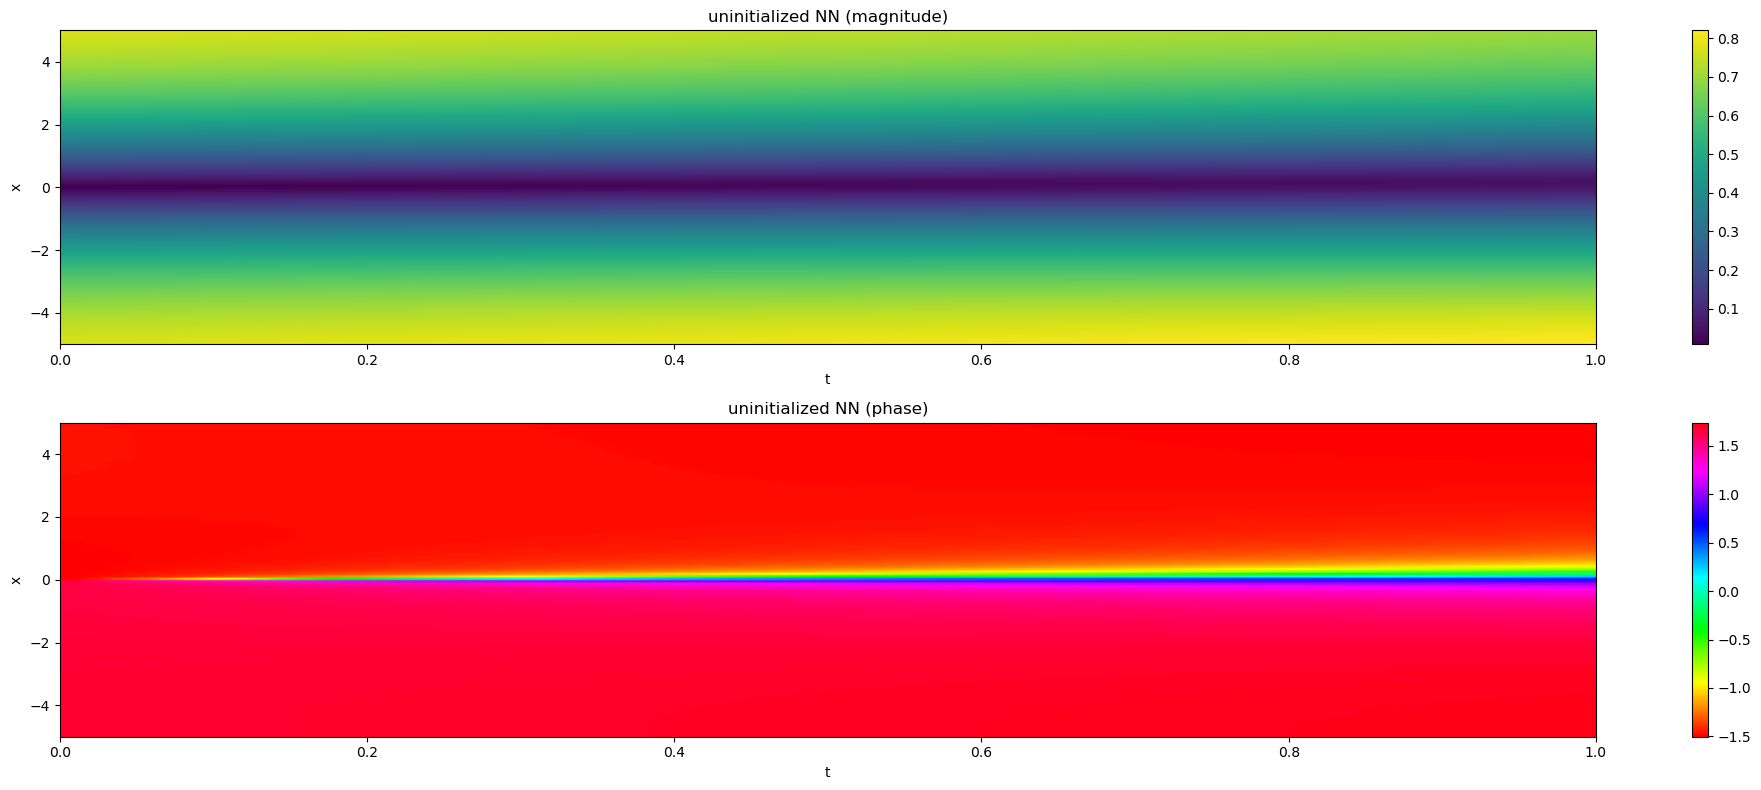

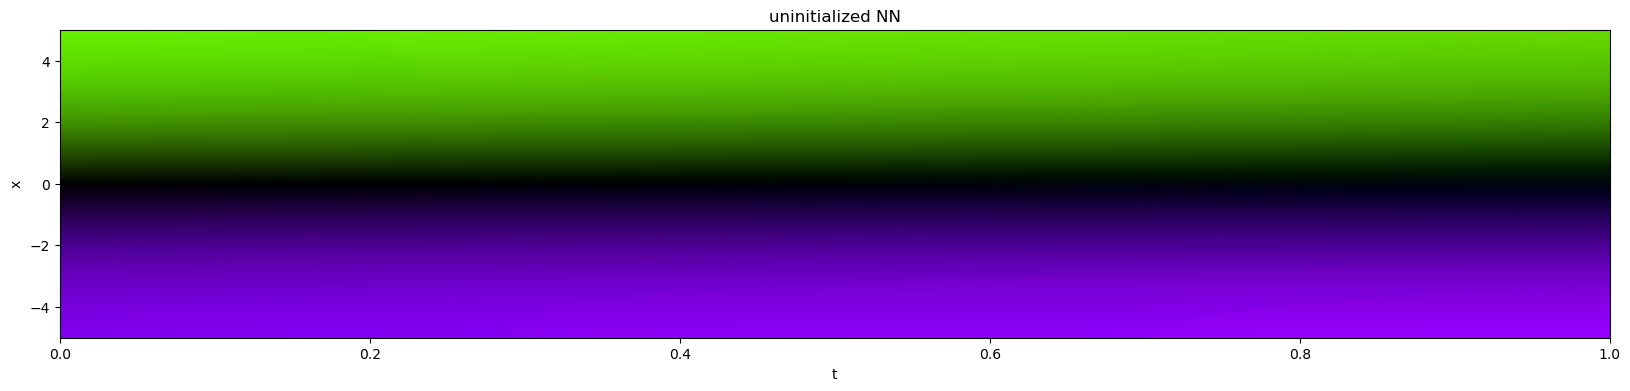

In [4]:
neural_network.show_state("uninitialized NN", 'real_imag');
neural_network.show_state("uninitialized NN", 'mag_phase');
neural_network.show_state("uninitialized NN", 'complex');

In [5]:
# optimizer = keras.optimizers.SGD(learning_rate=0.02)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
neural_network.model.compile(optimizer)

In [6]:
EPOCHS = 10000
history = {"loss": [], "loss_init": [], "loss_bound": [], "loss_bulk": []}
for epoch in range(1, EPOCHS + 1):
    loss, loss_init, loss_bound, loss_bulk = neural_network.train_step(optimizer)
    history["loss"].append(float(loss))
    history["loss_init"].append(float(loss_init))
    history["loss_bound"].append(float(loss_bound))
    history["loss_bulk"].append(float(loss_bulk))
    if epoch % 500 == 0 or epoch == 1:
        print(f"epoch {epoch:5d} | loss {loss:.4e} | init {loss_init:.2e} | bound {loss_bound:.2e} | bulk {loss_bulk:.2e}")
    if epoch % 2000 == 0:
        new_LR = optimizer.learning_rate.numpy() / 2
        optimizer.learning_rate.assign(new_LR)

epoch     1 | loss 1.7387e+00 | init 5.35e-01 | bound 1.18e+00 | bulk 2.52e-02
epoch   500 | loss 3.3299e-02 | init 1.63e-02 | bound 6.92e-03 | bulk 1.01e-02
epoch  1000 | loss 1.7990e-02 | init 1.12e-02 | bound 9.82e-05 | bulk 6.67e-03
epoch  1500 | loss 1.4352e-02 | init 8.54e-03 | bound 1.09e-04 | bulk 5.70e-03
epoch  2000 | loss 1.0923e-02 | init 7.41e-03 | bound 4.58e-05 | bulk 3.47e-03
epoch  2500 | loss 9.3434e-03 | init 6.24e-03 | bound 1.33e-05 | bulk 3.09e-03
epoch  3000 | loss 8.6458e-03 | init 6.06e-03 | bound 2.23e-05 | bulk 2.57e-03
epoch  3500 | loss 6.8826e-03 | init 4.56e-03 | bound 1.51e-04 | bulk 2.18e-03
epoch  4000 | loss 5.9339e-03 | init 3.96e-03 | bound 1.68e-05 | bulk 1.96e-03
epoch  4500 | loss 5.4773e-03 | init 3.65e-03 | bound 8.04e-06 | bulk 1.82e-03
epoch  5000 | loss 4.9681e-03 | init 3.30e-03 | bound 8.50e-06 | bulk 1.66e-03
epoch  5500 | loss 4.5637e-03 | init 2.99e-03 | bound 6.56e-05 | bulk 1.51e-03
epoch  6000 | loss 8.2914e-03 | init 3.18e-03 | boun

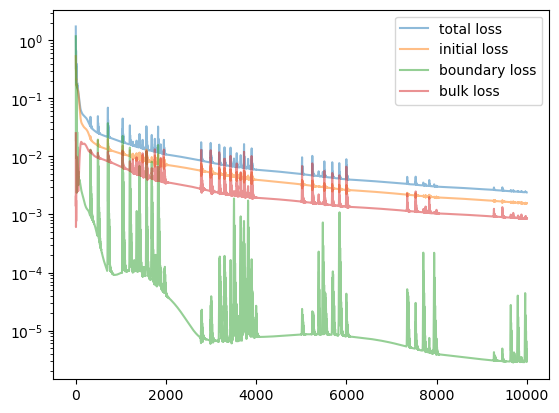

In [7]:
plt.yscale('log')
plt.plot(history['loss'], alpha=0.5, label='total loss')
plt.plot(history['loss_init'], alpha=0.5, label='initial loss')
plt.plot(history['loss_bound'], alpha=0.5, label='boundary loss')
plt.plot(history['loss_bulk'], alpha=0.5, label='bulk loss')
plt.legend();

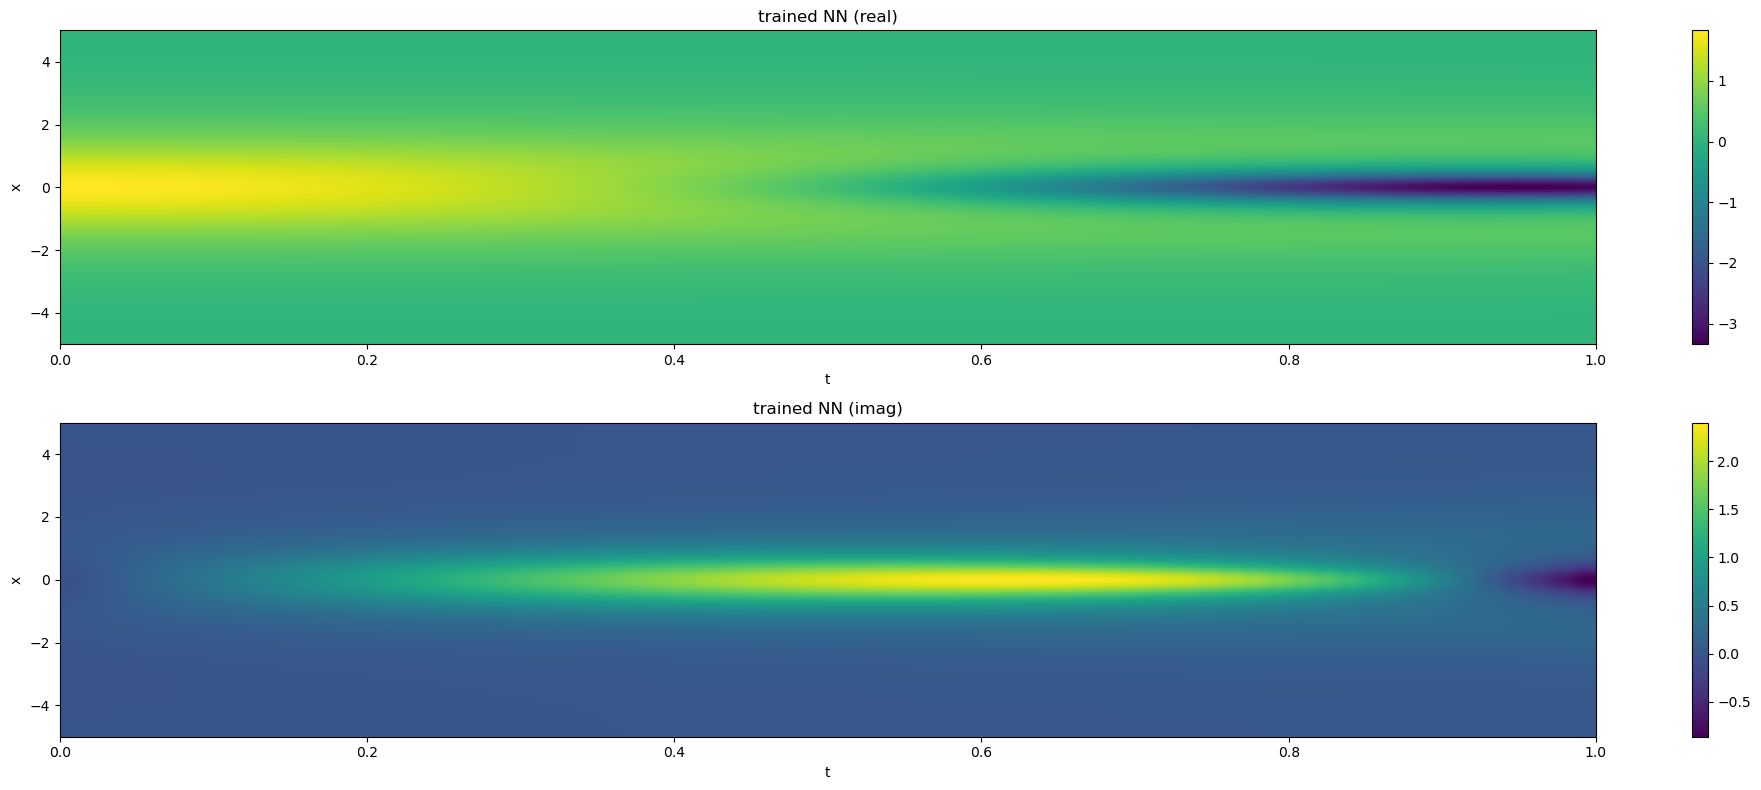

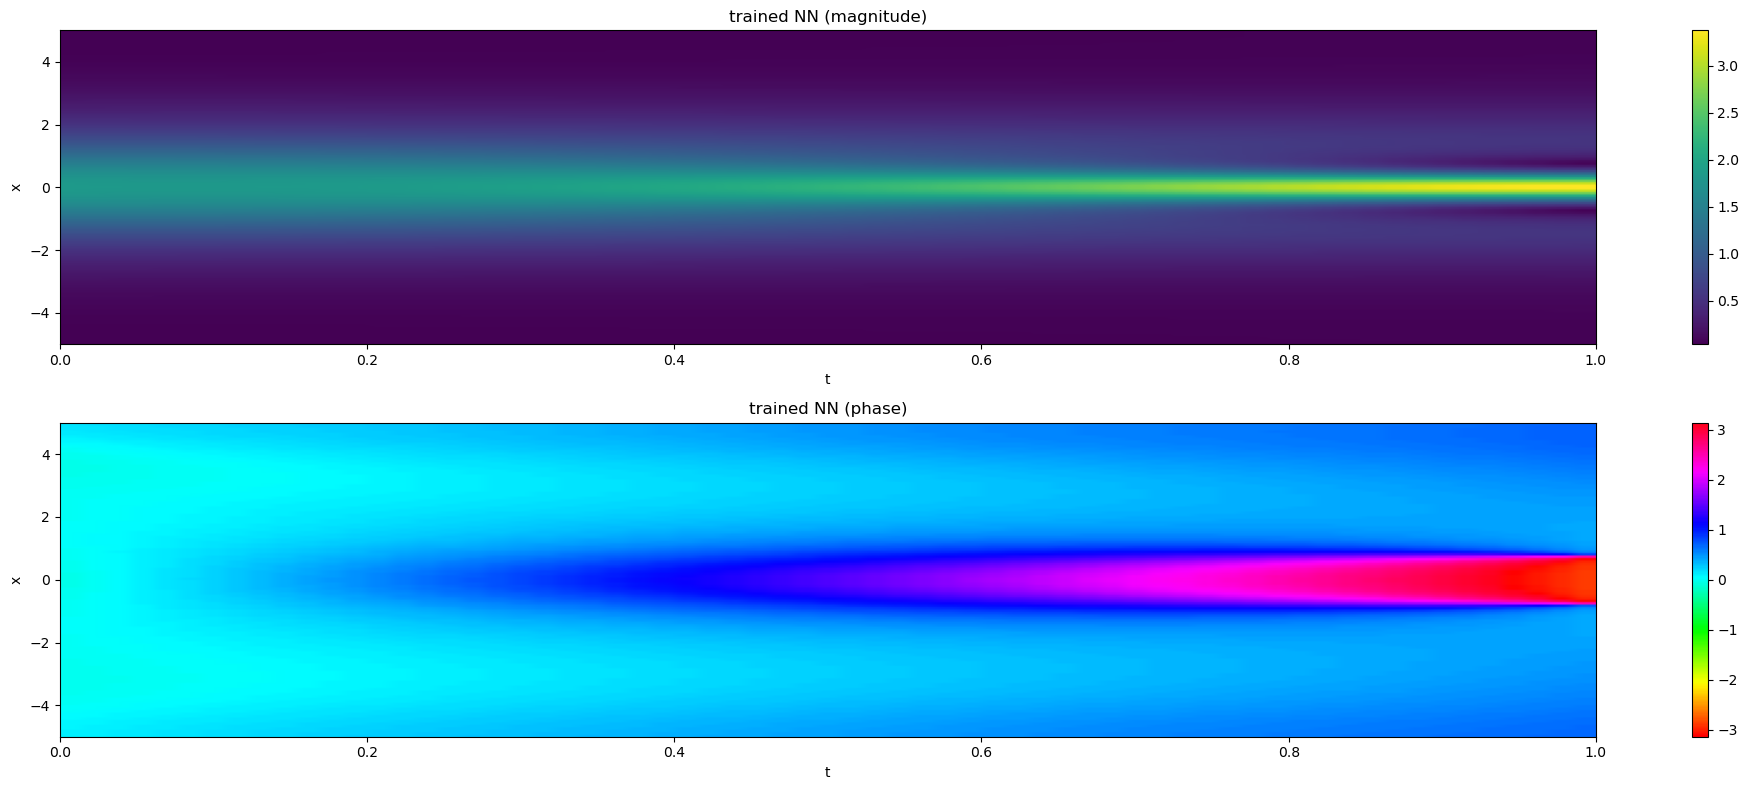

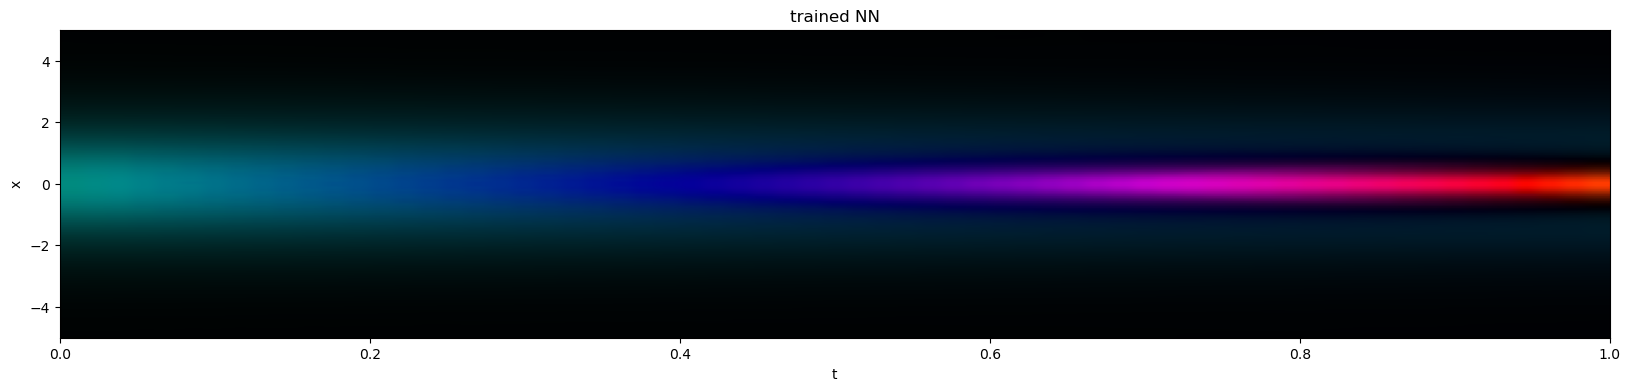

In [8]:
neural_network.show_state("trained NN", 'real_imag');
neural_network.show_state("trained NN", 'mag_phase');
neural_network.show_state("trained NN", 'complex');

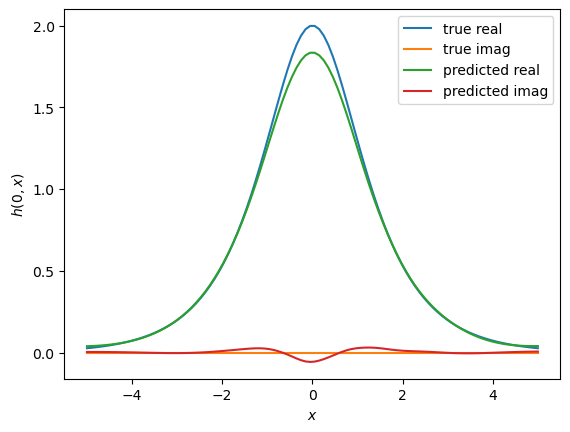

In [13]:
plt.plot(np.linspace(-5, 5, 100), 2/np.cosh(np.linspace(-5, 5, 100)), label="true real")
plt.plot(np.linspace(-5, 5, 100), np.zeros(100), label="true imag")
plt.plot(np.linspace(-5, 5, 100), neural_network.h(
    tf.zeros(100), tf.convert_to_tensor(np.linspace(-5, 5, 100), dtype=tf.float32)
)[:,0], label="predicted real")
plt.plot(np.linspace(-5, 5, 100), neural_network.h(
    tf.zeros(100), tf.convert_to_tensor(np.linspace(-5, 5, 100), dtype=tf.float32)
)[:,1], label="predicted imag")
plt.xlabel('$x$')
plt.ylabel('$h(0,x)$')
plt.legend();

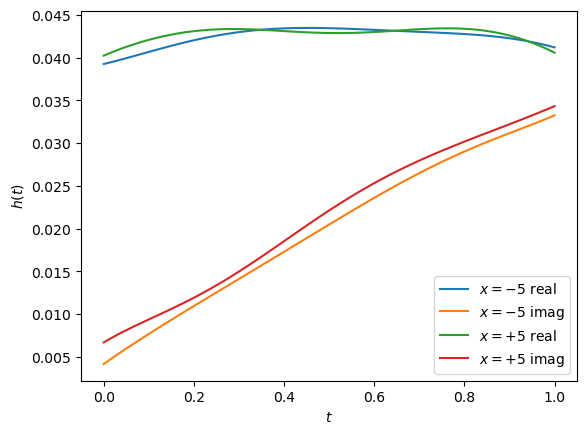

In [14]:
plt.plot(np.linspace(0, 1, 100), neural_network.h(
    tf.convert_to_tensor(np.linspace(0, 1, 100), dtype=tf.float32), -5*tf.ones(100)
)[:,0], label="$x = -5$"+" real")
plt.plot(np.linspace(0, 1, 100), neural_network.h(
    tf.convert_to_tensor(np.linspace(0, 1, 100), dtype=tf.float32), -5*tf.ones(100)
)[:,1], label="$x = -5$"+" imag")
plt.plot(np.linspace(0, 1, 100), neural_network.h(
    tf.convert_to_tensor(np.linspace(0, 1, 100), dtype=tf.float32), 5*tf.ones(100)
)[:,0], label="$x = +5$"+" real")
plt.plot(np.linspace(0, 1, 100), neural_network.h(
    tf.convert_to_tensor(np.linspace(0, 1, 100), dtype=tf.float32), 5*tf.ones(100)
)[:,1], label="$x = +5$"+" imag")
plt.xlabel('$t$')
plt.ylabel('$h(t)$')
plt.legend();

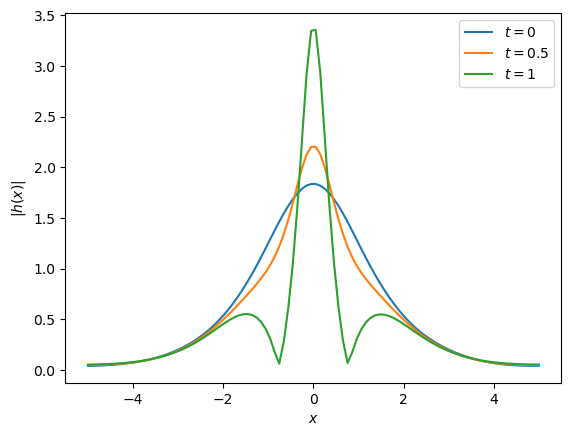

In [15]:
h = neural_network.h(tf.zeros(100), tf.convert_to_tensor(np.linspace(-5, 5, 100), dtype=tf.float32))
plt.plot(np.linspace(-5, 5, 100), np.sqrt(np.sum(h**2, axis=-1)), label="$t = 0$")
h = neural_network.h(tf.zeros(100)+0.5, tf.convert_to_tensor(np.linspace(-5, 5, 100), dtype=tf.float32))
plt.plot(np.linspace(-5, 5, 100), np.sqrt(np.sum(h**2, axis=-1)), label="$t = 0.5$")
h = neural_network.h(tf.zeros(100)+1., tf.convert_to_tensor(np.linspace(-5, 5, 100), dtype=tf.float32))
plt.plot(np.linspace(-5, 5, 100), np.sqrt(np.sum(h**2, axis=-1)), label="$t = 1$")
plt.xlabel('$x$')
plt.ylabel('$|h(x)|$')
plt.legend();